### Introduction


#### Demographic Information
*   **`Gender`**: Gender of the individual 
*   **`Age`**: Age of the individual in years 
*   **`Height`**: Height of the individual in meters 
*   **`Weight`**: Weight of the individual in kilograms 

#### Eating Habits
*   **`family_history_with_overweight`**: Has a family member suffered or suffers from overweight? 
*   **`FAVC`**: Do you eat high caloric food frequently? 
*   **`FCVC`**: Do you usually eat vegetables in your meals? 
*   **`NCP`**: How many main meals do you have daily? 
*   **`CAEC`**: Do you eat any food between meals? 
*   **`CH2O`**: How much water do you drink daily? 
*   **`CALC`**: How often do you drink alcohol? 

#### Physical Condition & Lifestyle
*   **`SMOKE`**: Do you smoke? 
*   **`SCC`**: Do you monitor the calories you eat daily? 
*   **`FAF`**: How often do you have physical activity? 
*   **`TUE`**: How much time do you use technological devices daily? 
*   **`MTRANS`**: What transportation do you usually use? 
---
#### Target Variable
*   **`NObeyesdad`** (or **`NObesity`**): 
    *   `Insufficient Weight`
    *   `Normal Weight`
    *   `Overweight Level I`
    *   `Overweight Level II`
    *   `Obesity Type I`
    *   `Obesity Type II`
    *   `Obesity Type III`

### Imports ###

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report




## Initial Look at the Dataset

### Load Dataset

In [29]:
df = pd.read_csv("dataset.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### EDA

In [30]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [31]:
df.shape

(2111, 17)

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [33]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

### Feature Engineering

In [37]:
# Convert kg to lbs
df['Weight_lbs'] = df['Weight'] * 2.20462   

In [38]:
# Convert meters to inches
df['Height_in'] = df['Height'] * 39.3701

In [43]:
# Calculate BMI and round to 1 decimal place
df['BMI'] = (df['Weight_lbs'] / (df['Height_in'] ** 2)) * 703
df['BMI'] = df['BMI'].round(1)

In [39]:
# Drop the height and weight columns
df = df.drop(columns=['Height', 'Weight'])

In [64]:
df.rename(columns={'NObeyesdad': 'Obesity_Class'}, inplace=True)

### Visualize Data

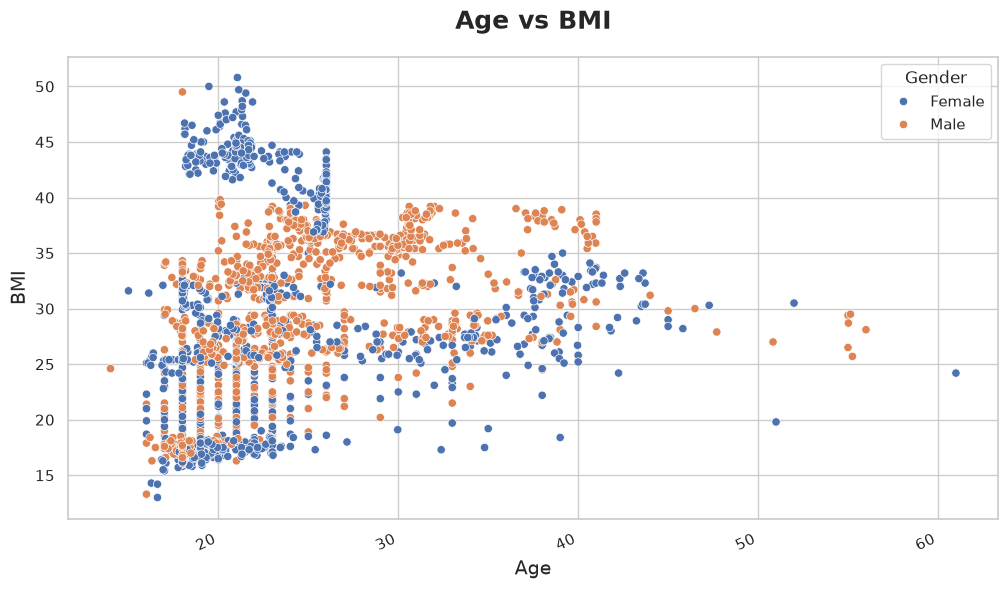

In [55]:
plt.figure(figsize=(12, 6))
# Title and labels
plt.title("Age vs BMI", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Age", fontsize=14)
plt.ylabel("BMI", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)
sns.scatterplot(data=df, x="Age", y="BMI", hue="Gender")
plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

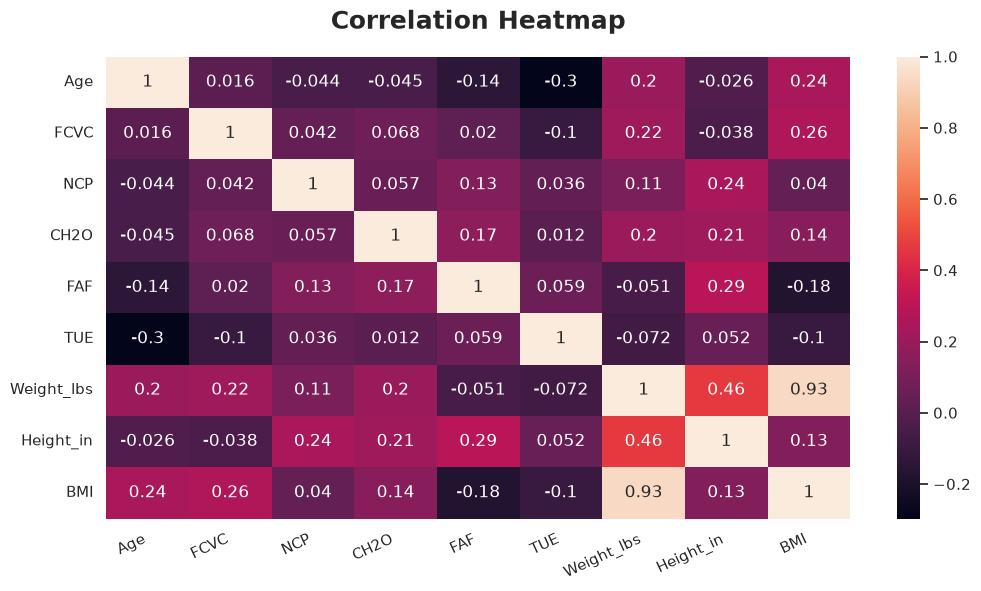

In [54]:
plt.figure(figsize=(12, 6))

# Title and labels
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold", pad=20)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Create figure

sns.heatmap(df.corr(numeric_only=True), annot=True)

/tmp/ipykernel_1151/2761151806.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


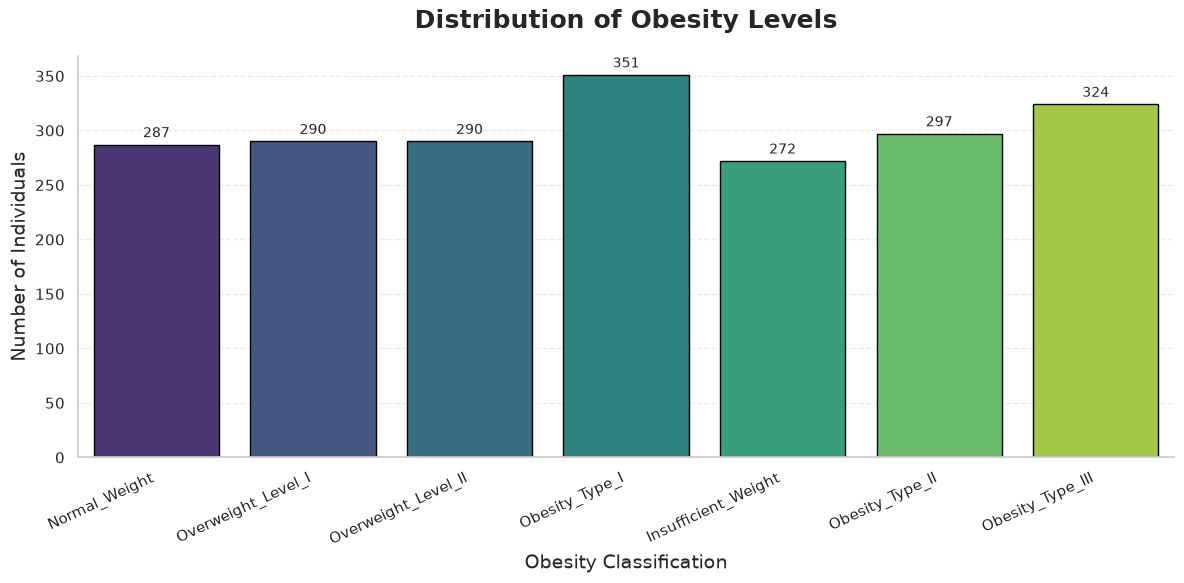

In [36]:
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Create count plot
ax = sns.countplot(
    data=df,
    x="NObeyesdad",
    palette="viridis",
    legend=False,
    edgecolor="black"
)

# Title and labels
plt.title("Distribution of Obesity Levels", fontsize=18, fontweight="bold", pad=20)
plt.xlabel("Obesity Classification", fontsize=14)
plt.ylabel("Number of Individuals", fontsize=14)

# Rotate x-axis labels
plt.xticks(rotation=25, ha="right", fontsize=11)
plt.yticks(fontsize=11)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=10, padding=3)

# Improve appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [65]:
df.columns

Index(['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity_Class', 'Weight_lbs', 'Height_in', 'BMI'],
      dtype='str')

### Train/Test Split

In [67]:
X = df.drop(columns=['Obesity_Class'])
y = df['Obesity_Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [75]:
preprocessor = make_column_transformer(
      (StandardScaler(),
       make_column_selector(dtype_include=np.number)),  
      (OneHotEncoder(),
       make_column_selector(dtype_include=[object, "string"]))) 

## Models

### Decision Tree


### Logistic Regression

In [83]:
logistic_regression_pipe = Pipeline([('preprocessor', preprocessor),
                 ('model', LogisticRegression(random_state=42, max_iter=300))])

logistic_regression_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](7,)","['Insufficient_Weight','Normal_Weight','Obesity_Type_I',..., 'Obesity_Type_III','Overweight_Level_I','Overweight_Level_II']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Gender','Age','family_history_with_overweight',...,'Weight_lbs', 'Height_in','BMI']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` ar

In [85]:
y_pred = logistic_regression_pipe.predict(X_test)

In [92]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.896700143472023
                     precision    recall  f1-score   support

Insufficient_Weight       0.87      0.99      0.93        90
      Normal_Weight       0.89      0.76      0.82       103
     Obesity_Type_I       0.97      0.92      0.95       114
    Obesity_Type_II       0.92      1.00      0.96        94
   Obesity_Type_III       1.00      0.99      1.00       115
 Overweight_Level_I       0.81      0.74      0.78        94
Overweight_Level_II       0.77      0.86      0.82        87

           accuracy                           0.90       697
          macro avg       0.89      0.90      0.89       697
       weighted avg       0.90      0.90      0.90       697

[[ 89   1   0   0   0   0   0]
 [ 13  78   0   0   0   7   5]
 [  0   0 105   7   0   0   2]
 [  0   0   0  94   0   0   0]
 [  0   0   0   1 114   0   0]
 [  0   9   0   0   0  70  15]
 [  0   0   3   0   0   9  75]]


### AutoML

### Random Forest

### Nueral Network

## Compare Models

### Confusion Matrix

## Conclusions